

## Aim
The aim of this project is to develop and evaluate forecasting models for **hourly NO₂ concentrations** at the **London Bloomsbury (CLL2) AURN monitoring site** using historical air-quality time-series data.

## Research Question
**RQ:** How accurately can we forecast **NO₂ at time t+1 (1-hour ahead)** using historical pollutant measurements and time-based features?


## Objectives
1. Collect and clean hourly air-quality data (2015–2025) from DEFRA/UK-AIR.
2. Perform exploratory data analysis (EDA) to understand trends, seasonality, and missingness.
3. Create forecasting datasets using leakage-safe preprocessing (chronological split, train-only scaling).
4. Build and evaluate multiple forecasting models:
   - **Naive baseline** (persistence)
   - **XGBoost regression**
   - **LSTM neural network**
5. Compare models using consistent evaluation metrics (MAE, RMSE) on validation and test sets.
6. Discuss results, limitations, and future improvements.

## Models Compared
We compare the following approaches for the same forecasting task (t+1):

- **Naive persistence baseline:**  
  Predict NO₂(t+1) = NO₂(t)

- **XGBoost (Gradient Boosted Trees):**  
  Supervised learning using engineered lag and rolling-window features

- **LSTM (Recurrent Neural Network):**  
  Sequence learning model using historical time windows of multivariate inputs

## Evaluation Metrics
We evaluate performance using:
- **MAE (Mean Absolute Error)**  
- **RMSE (Root Mean Squared Error)**  

Metrics are reported on:
- Validation set (for hyperparameter selection)
- Test set (final generalization performance)

## Data Split (Chronological)
- **Train:** 2015–2021  
- **Validation:** 2022–2023  
- **Test:** 2024–2025

(Chronological splits are used to avoid data leakage.)

## 1) Imports
This section loads all required Python libraries used throughout the notebook.


In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## 2) Configuration (project settings)
All key parameters (paths, split dates, horizon, window length) are defined here so the notebook is reproducible.

In [ ]:
FILES = [
    "/content/CLL2_2015.csv",
    "/content/CLL2_2016.csv",
    "/content/CLL2_2017.csv",
    "/content/CLL2_2018.csv",
    "/content/CLL2_2019.csv",
    "/content/CLL2_2020.csv",
    "/content/CLL2_2021.csv",
    "/content/CLL2_2022.csv",
    "/content/CLL2_2023.csv",
    "/content/CLL2_2024.csv",
    "/content/CLL2_2025 (1).csv",
]

SITE_NAME = "London Bloomsbury (CLL2)"
WINDOW = 48          #
HORIZON = 1          # t+1 forecasting
TARGET_COL = "target_t_plus_1"
SHORT_GAP_LIMIT_HOURS = 3

TRAIN_START = "2015-01-01"
TRAIN_END   = "2021-12-31 23:00:00"
VAL_START   = "2022-01-01"
VAL_END     = "2023-12-31 23:00:00"
TEST_START  = "2024-01-01"
TEST_END    = "2025-12-31 23:00:00"

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 3) Data loading and cleaning
Load DEFRA hourly data, fix timestamps, and combine yearly files into one clean hourly dataframe.

In [ ]:
# ============================================================
# 1) DEFRA / UK-AIR LOADING
# ============================================================
def find_header_row(path: str, needle="Date,time") -> int:
    with open(path, "r", encoding="utf-8-sig", errors="replace") as f:
        for i, line in enumerate(f):
            if line.strip().startswith(needle):
                return i
    raise ValueError(f"Could not find header row in {path}")

def load_ukair_csv(path: str, hour_ending: bool = True) -> pd.DataFrame:
    header_row = find_header_row(path)

    df = pd.read_csv(
        path,
        skiprows=header_row,
        encoding="utf-8-sig",
        engine="python",
        skip_blank_lines=True,
        on_bad_lines="warn",
    )
    df.columns = [str(c).strip() for c in df.columns]

    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

    t = df["time"].astype(str).str.strip()
    is24 = t.eq("24:00")
    t = t.mask(is24, "00:00")

    dt = pd.to_datetime(df["Date"].dt.strftime("%Y-%m-%d") + " " + t, errors="coerce")
    dt = dt + pd.to_timedelta(is24.astype(int), unit="D")

    # hour-ending -> hour-start
    if hour_ending:
        dt = dt - pd.Timedelta(hours=1)

    df.insert(0, "datetime", dt)
    df = df.drop(columns=["Date", "time"], errors="ignore")
    df = df.dropna(subset=["datetime"]).sort_values("datetime")
    df = df.drop_duplicates(subset=["datetime"], keep="last")
    df = df.set_index("datetime").sort_index()

    return df.asfreq("h")

def load_all_files(files, hour_ending=True) -> pd.DataFrame:
    dfs = []
    for fp in files:
        if Path(fp).exists():
            print("Loading:", Path(fp).name)
            dfs.append(load_ukair_csv(fp, hour_ending=hour_ending))
        else:
            print("Missing:", fp)

    if not dfs:
        raise ValueError("No files loaded. Check paths.")

    df_all = pd.concat(dfs, axis=0, sort=False).sort_index()
    df_all = df_all[~df_all.index.duplicated(keep="last")].sort_index()
    return df_all.asfreq("h")

## 4) Load and unify yearly datasets (2015–2025)

In [ ]:
df_all = load_all_files(FILES, hour_ending=True)
print("\n=== df_all ===")
print("Shape:", df_all.shape)
print("Range:", df_all.index.min(), "->", df_all.index.max())

Loading: CLL2_2015.csv
Loading: CLL2_2016.csv
Loading: CLL2_2017.csv
Loading: CLL2_2018.csv
Loading: CLL2_2019.csv
Loading: CLL2_2020.csv
Loading: CLL2_2021.csv
Loading: CLL2_2022.csv
Loading: CLL2_2023.csv
Loading: CLL2_2024.csv
Loading: CLL2_2025 (1).csv

=== df_all ===
Shape: (96432, 33)
Range: 2015-01-01 00:00:00 -> 2025-12-31 23:00:00


## 5) Build modelling dataframe (pollutants + time features)
Create the core modelling variables (NO₂, NO, NOx, O₃) and time-based features used in later EDA and modelling.

In [ ]:
# ============================================================
# 2) BUILD RAW POLLUTANTS + TIME FEATURES
# ============================================================
COL_NO2 = "Nitrogen dioxide"
COL_NO  = "Nitric oxide"
COL_NOX = "Nitrogen oxides as nitrogen dioxide"
COL_O3  = "Ozone"

missing_cols = [c for c in [COL_NO2, COL_NO, COL_NOX, COL_O3] if c not in df_all.columns]
if missing_cols:
    print("Available columns (first 100):")
    print(df_all.columns.tolist()[:100])
    raise ValueError(f"Missing AQ columns: {missing_cols}")

base = pd.DataFrame(index=df_all.index)
base["no2"] = pd.to_numeric(df_all[COL_NO2], errors="coerce")
base["no"]  = pd.to_numeric(df_all[COL_NO],  errors="coerce")
base["nox"] = pd.to_numeric(df_all[COL_NOX], errors="coerce")
base["o3"]  = pd.to_numeric(df_all[COL_O3],  errors="coerce")

# time features
base["hour"] = base.index.hour
base["dayofweek"] = base.index.dayofweek
base["month"] = base.index.month
base["is_weekend"] = (base["dayofweek"] >= 5).astype(int)

base["hour_sin"]  = np.sin(2*np.pi*base["hour"]/24)
base["hour_cos"]  = np.cos(2*np.pi*base["hour"]/24)
base["dow_sin"]   = np.sin(2*np.pi*base["dayofweek"]/7)
base["dow_cos"]   = np.cos(2*np.pi*base["dayofweek"]/7)
base["month_sin"] = np.sin(2*np.pi*(base["month"]-1)/12)
base["month_cos"] = np.cos(2*np.pi*(base["month"]-1)/12)

## 5) Exploratory Data Analysis (EDA)
We explore the dataset to understand missingness, trends, seasonality, and pollutant relationships. These findings guide preprocessing (gap handling) and feature engineering for forecasting models.



EDA range: 2015-01-01 00:00:00 -> 2025-12-31 23:00:00
Core columns: ['no2', 'no', 'nox', 'o3']


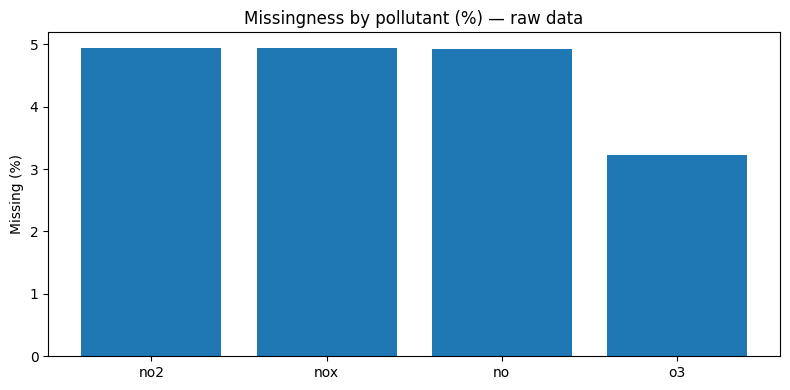

Missingness (%):
 no2    4.94
nox    4.94
no     4.93
o3     3.22
dtype: float64


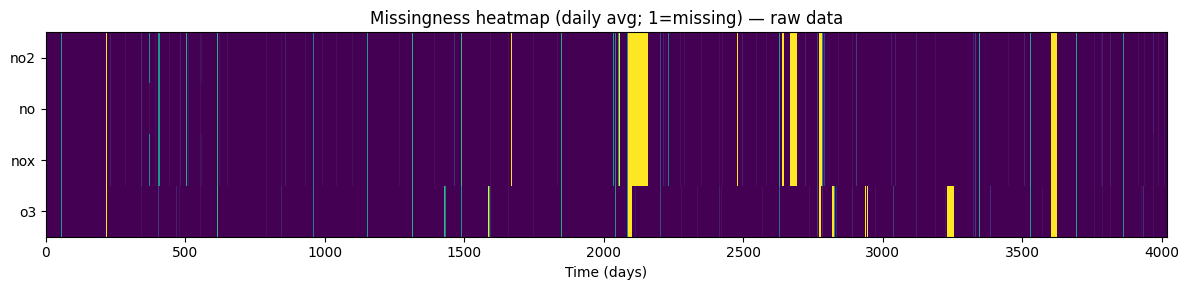

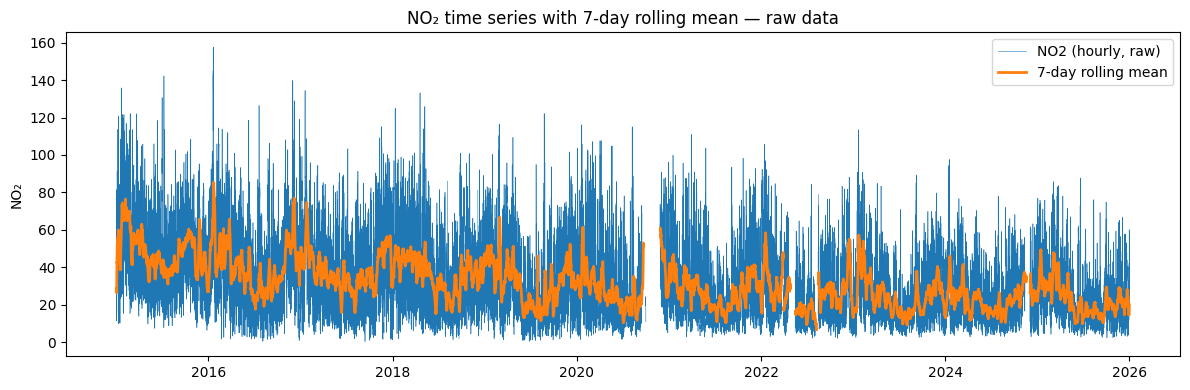

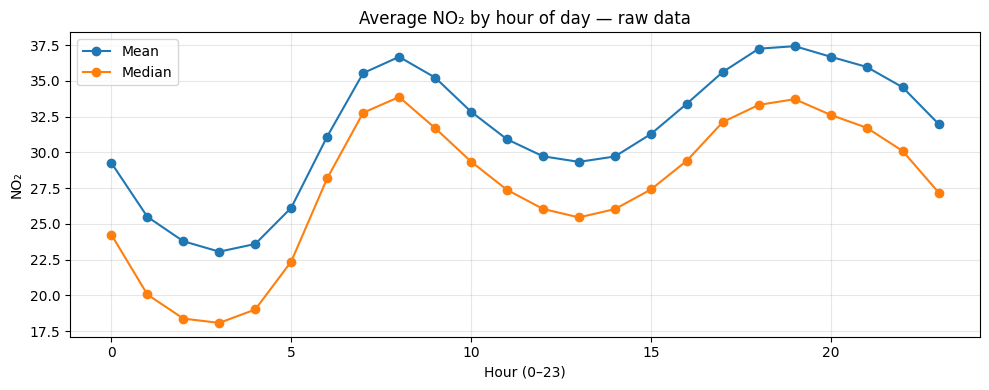

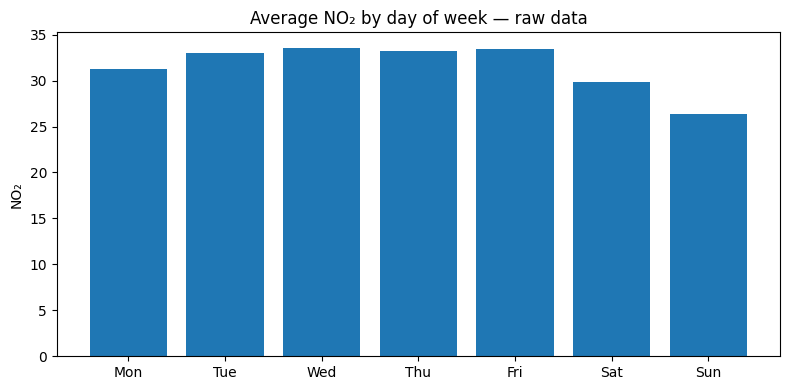

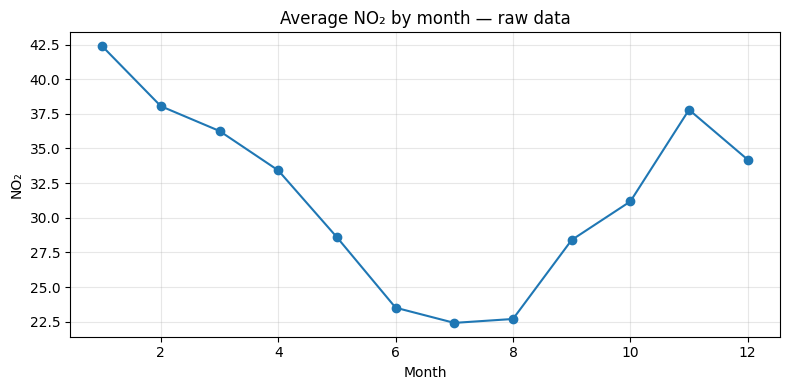

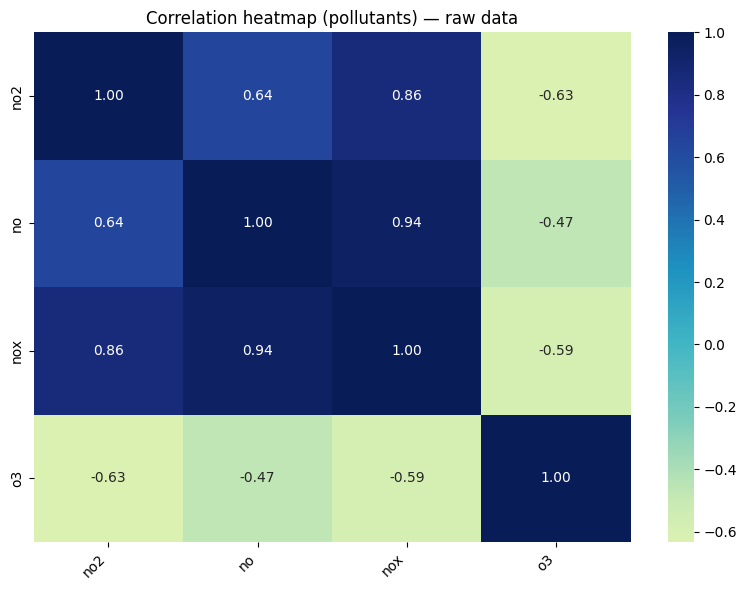

Correlation matrix:
        no2     no    nox     o3
no2  1.000  0.641  0.857 -0.633
no   0.641  1.000  0.945 -0.471
nox  0.857  0.945  1.000 -0.586
o3  -0.633 -0.471 -0.586  1.000


In [ ]:
# ============================================================
# EDA
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

eda = base.copy().sort_index()
core_cols = [c for c in ["no2", "no", "nox", "o3"] if c in eda.columns]

print("EDA range:", eda.index.min(), "->", eda.index.max())
print("Core columns:", core_cols)

# ------------------------------------------------------------
# 1) Missingness % per pollutant
# ------------------------------------------------------------
missing_pct = (eda[core_cols].isna().mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(8,4))
plt.bar(missing_pct.index, missing_pct.values)
plt.title("Missingness by pollutant (%) — raw data")
plt.ylabel("Missing (%)")
plt.tight_layout()
plt.show()

print("Missingness (%):\n", missing_pct.round(2))

# ------------------------------------------------------------
# 2) Missingness heatmap over time (daily average)
# ------------------------------------------------------------
miss_map = eda[core_cols].isna().astype(int)
miss_daily = miss_map.resample("D").mean()

plt.figure(figsize=(12,3))
plt.imshow(miss_daily.T, aspect="auto", interpolation="nearest")
plt.yticks(range(len(core_cols)), core_cols)
plt.title("Missingness heatmap (daily avg; 1=missing) — raw data")
plt.xlabel("Time (days)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3) NO2 time series + 7-day rolling mean (raw)
# ------------------------------------------------------------
if "no2" in eda.columns:
    plt.figure(figsize=(12,4))
    plt.plot(eda.index, eda["no2"], linewidth=0.4, label="NO2 (hourly, raw)")
    plt.plot(eda["no2"].rolling(24*7, min_periods=24).mean(), linewidth=2, label="7-day rolling mean")
    plt.title("NO₂ time series with 7-day rolling mean — raw data")
    plt.ylabel("NO₂")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 4) Seasonality: average NO2 by hour-of-day
# ------------------------------------------------------------
if "no2" in eda.columns:
    tmp = eda[["no2"]].dropna().copy()
    tmp["hour"] = tmp.index.hour
    hour_mean = tmp.groupby("hour")["no2"].mean()
    hour_med  = tmp.groupby("hour")["no2"].median()

    plt.figure(figsize=(10,4))
    plt.plot(hour_mean.index, hour_mean.values, marker="o", label="Mean")
    plt.plot(hour_med.index,  hour_med.values,  marker="o", label="Median")
    plt.title("Average NO₂ by hour of day — raw data")
    plt.xlabel("Hour (0–23)")
    plt.ylabel("NO₂")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 5) Seasonality: average NO2 by day-of-week
# ------------------------------------------------------------
if "no2" in eda.columns:
    tmp = eda[["no2"]].dropna().copy()
    tmp["dow"] = tmp.index.dayofweek  # 0=Mon ... 6=Sun
    dow_mean = tmp.groupby("dow")["no2"].mean()

    dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

    plt.figure(figsize=(8,4))
    plt.bar(range(7), dow_mean.values)
    plt.xticks(range(7), dow_labels)
    plt.title("Average NO₂ by day of week — raw data")
    plt.ylabel("NO₂")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 6) Seasonality: average NO2 by month
# ------------------------------------------------------------
if "no2" in eda.columns:
    tmp = eda[["no2"]].dropna().copy()
    tmp["month"] = tmp.index.month
    month_mean = tmp.groupby("month")["no2"].mean()

    plt.figure(figsize=(8,4))
    plt.plot(month_mean.index, month_mean.values, marker="o")
    plt.title("Average NO₂ by month — raw data")
    plt.xlabel("Month")
    plt.ylabel("NO₂")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 7) Correlation heatmap (pollutants) - Seaborn Version
# ------------------------------------------------------------
corr_df = eda[core_cols].dropna()
corr = corr_df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(corr, annot=True, fmt=".2f", cmap='YlGnBu', center=0)

plt.title("Correlation heatmap (pollutants) — raw data")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Correlation matrix:\n", corr.round(3))

## 6) Preprocessing
We apply short-gap interpolation (≤3 hours), engineer features, define the forecasting target, and create leakage-safe train/validation/test splits before scaling and preparing model inputs.

### 6.1 Missing data handling (short-gap interpolation)
We interpolate only short gaps (≤ 3 hours) in the pollutant time series to preserve continuity. Longer gaps are left as missing and will be handled later by dropping affected model windows.

In [ ]:
base_interp = base.copy()
raw_pollutants = ["no2", "no", "nox", "o3"]

base_interp[raw_pollutants] = base_interp[raw_pollutants].interpolate(
    method="time",
    limit=SHORT_GAP_LIMIT_HOURS,
    limit_direction="both"
)

print("\nMissingness after interp (raw pollutants) %:")
print((base_interp[raw_pollutants].isna().mean()*100).round(2))


Missingness after interp (raw pollutants) %:
no2    4.33
no     4.33
nox    4.33
o3     2.73
dtype: float64


6.2
Defining target for the models

In [ ]:
base_interp[TARGET_COL] = base_interp["no2"].shift(-HORIZON)

6.3 Dataset splitting for training, validation and testing.

In [ ]:
TRAIN_IDX = base_interp.loc[TRAIN_START:TRAIN_END].index
VAL_IDX   = base_interp.loc[VAL_START:VAL_END].index
TEST_IDX  = base_interp.loc[TEST_START:TEST_END].index

def split_any(df: pd.DataFrame):

    train = df.loc[df.index.intersection(TRAIN_IDX)].copy()
    val   = df.loc[df.index.intersection(VAL_IDX)].copy()
    test  = df.loc[df.index.intersection(TEST_IDX)].copy()
    return train, val, test

print("\nCommon split index sizes (hours):", len(TRAIN_IDX), len(VAL_IDX), len(TEST_IDX))



Common split index sizes (hours): 61368 17520 17544


### 6.4 LSTM feature engineering (compact feature set)
LSTM consumes a sequence window of past observations, so we use a compact feature set:
- **Raw pollutants:** no2, no, nox, o3  
- **Time encodings:** hour_sin/cos, dow_sin/cos, month_sin/cos, is_weekend  
- **Selected engineered NO₂ summaries:** key lags (1, 24, 48, 168), rolling mean/std, and differences (1, 24)



In [ ]:
# ============================================================
# 6A) LSTM FEATURE ENGINEERING (compact) -> lstm_forecast_df
# ============================================================
lstm_df = base_interp.copy()

# Key lags
lstm_df["no2_lag1"]   = lstm_df["no2"].shift(1)
lstm_df["no2_lag24"]  = lstm_df["no2"].shift(24)
lstm_df["no2_lag48"]  = lstm_df["no2"].shift(48)
lstm_df["no2_lag168"] = lstm_df["no2"].shift(168)

# Rolling stats (past-only)
lstm_df["no2_roll_mean_3"]  = lstm_df["no2"].rolling(3).mean()
lstm_df["no2_roll_mean_24"] = lstm_df["no2"].rolling(24).mean()
lstm_df["no2_roll_std_24"]  = lstm_df["no2"].rolling(24).std()

# Differences
lstm_df["no2_diff1"]  = lstm_df["no2"] - lstm_df["no2"].shift(1)
lstm_df["no2_diff24"] = lstm_df["no2"] - lstm_df["no2"].shift(24)

LSTM_FEATURE_COLS = [
    "no2","no","nox","o3",
    "no2_lag1","no2_lag24","no2_lag48","no2_lag168",
    "no2_roll_mean_3","no2_roll_mean_24","no2_roll_std_24",
    "no2_diff1","no2_diff24",
    "is_weekend","hour_sin","hour_cos","dow_sin","dow_cos","month_sin","month_cos",
]

lstm_forecast_df = lstm_df[LSTM_FEATURE_COLS + [TARGET_COL]].copy()

train_lstm_df, val_lstm_df, test_lstm_df = split_any(lstm_forecast_df)

print("\n=== LSTM splits (common split_any) ===")
print("Train:", train_lstm_df.shape, train_lstm_df.index.min(), "->", train_lstm_df.index.max())
print("Val  :", val_lstm_df.shape,   val_lstm_df.index.min(),   "->", val_lstm_df.index.max())
print("Test :", test_lstm_df.shape,  test_lstm_df.index.min(),  "->", test_lstm_df.index.max())


=== LSTM splits (common split_any) ===
Train: (61368, 21) 2015-01-01 00:00:00 -> 2021-12-31 23:00:00
Val  : (17520, 21) 2022-01-01 00:00:00 -> 2023-12-31 23:00:00
Test : (17544, 21) 2024-01-01 00:00:00 -> 2025-12-31 23:00:00


### 6.5 XGBoost feature engineering (expanded lag feature set)
XGBoost is a tabular model and does not take sequences directly, so temporal dependence is provided explicitly:
- **Lag features:** lag1…lag48 for each pollutant (no2, no, nox, o3)
- **Rolling statistics (NO₂):** rolling mean (3, 6, 24) and rolling std (24)
- **Differences (NO₂):** diff1 and diff24
- **Time encodings:** hour_sin/cos, dow_sin/cos, month_sin/cos, is_weekend

The code cell below constructs a supervised table `sup` used to train the XGBoost model.

In [ ]:
# ============================================================
# 6B) XGBOOST FEATURE ENGINEERING (wide lag table) -> sup
# ============================================================
xgb_df = base_interp.copy()

MAX_LAG = 48
lag_base_cols = ["no2", "no", "nox", "o3"]
for c in lag_base_cols:
    for lag in range(1, MAX_LAG + 1):
        xgb_df[f"{c}_lag{lag}"] = xgb_df[c].shift(lag)

# Rolling stats
xgb_df["no2_roll_mean_3"]  = xgb_df["no2"].rolling(3).mean()
xgb_df["no2_roll_mean_6"]  = xgb_df["no2"].rolling(6).mean()
xgb_df["no2_roll_mean_24"] = xgb_df["no2"].rolling(24).mean()
xgb_df["no2_roll_std_24"]  = xgb_df["no2"].rolling(24).std()

# Differences
xgb_df["no2_diff1"]  = xgb_df["no2"] - xgb_df["no2"].shift(1)
xgb_df["no2_diff24"] = xgb_df["no2"] - xgb_df["no2"].shift(24)

time_cols = ["is_weekend","hour_sin","hour_cos","dow_sin","dow_cos","month_sin","month_cos"]
eng_cols  = ["no2_roll_mean_3","no2_roll_mean_6","no2_roll_mean_24","no2_roll_std_24","no2_diff1","no2_diff24"]
lag_cols  = [c for c in xgb_df.columns if "_lag" in c]

XGB_FEATURE_COLS = lag_cols + eng_cols + time_cols

# Supervised table for XGBoost: drop rows with NaNs from lags/rollings/target
sup = xgb_df[XGB_FEATURE_COLS + [TARGET_COL]].dropna().copy()

train_sup, val_sup, test_sup = split_any(sup)

X_train, y_train = train_sup[XGB_FEATURE_COLS], train_sup[TARGET_COL]
X_val,   y_val   = val_sup[XGB_FEATURE_COLS],   val_sup[TARGET_COL]
X_test,  y_test  = test_sup[XGB_FEATURE_COLS],  test_sup[TARGET_COL]

print("\n=== XGBoost splits (common split_any) ===")
print("Train:", X_train.shape, X_train.index.min(), "->", X_train.index.max())
print("Val  :", X_val.shape,   X_val.index.min(),   "->", X_val.index.max())
print("Test :", X_test.shape,  X_test.index.min(),  "->", X_test.index.max())

print("\nNOTE:")
print("- Splitting is defined ONCE (TRAIN_IDX/VAL_IDX/TEST_IDX + split_any).")
print("- Row counts can still differ across models due to lag/rolling dropna (XGB)")
print("  and later sequence window dropping (LSTM). This is expected.")

/tmp/ipykernel_3518/2795432311.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  xgb_df[f"{c}_lag{lag}"] = xgb_df[c].shift(lag)
/tmp/ipykernel_3518/2795432311.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  xgb_df[f"{c}_lag{lag}"] = xgb_df[c].shift(lag)
/tmp/ipykernel_3518/2795432311.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragm


=== XGBoost splits (common split_any) ===
Train: (57134, 205) 2015-01-03 00:00:00 -> 2021-12-31 23:00:00
Val  : (14821, 205) 2022-01-01 00:00:00 -> 2023-12-31 23:00:00
Test : (16678, 205) 2024-01-01 00:00:00 -> 2025-12-31 22:00:00

NOTE:
- Splitting is defined ONCE (TRAIN_IDX/VAL_IDX/TEST_IDX + split_any).
- Row counts can still differ across models due to lag/rolling dropna (XGB)
  and later sequence window dropping (LSTM). This is expected.


## 7) Baseline model (naive persistence)
We use a simple persistence baseline for comparison: predict the next NO₂ value as the most recent observed value (e.g., NO₂(t+1) = NO₂(t)). This provides a minimum benchmark that more complex models should outperform.

In [ ]:
# ============================================================
# 7) BASELINE: Naive Persistence (t+1)
# y(t+1) = NO2(t)
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def reg_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

# True target (already defined earlier)
# base_interp["y"] = base_interp["no2"].shift(-HORIZON)

# Build baseline dataframe
baseline_df = pd.DataFrame(index=base_interp.index)
baseline_df["y_true"] = base_interp[TARGET_COL]
baseline_df["y_pred_naive"] = base_interp["no2"]  # persistence

# Split using common split
val_baseline  = baseline_df.loc[baseline_df.index.intersection(VAL_IDX)]
test_baseline = baseline_df.loc[baseline_df.index.intersection(TEST_IDX)]

# Drop rows with NaNs (due to shifting)
val_baseline  = val_baseline.dropna()
test_baseline = test_baseline.dropna()

# Compute metrics
val_mae, val_rmse   = reg_metrics(val_baseline["y_true"], val_baseline["y_pred_naive"])
test_mae, test_rmse = reg_metrics(test_baseline["y_true"], test_baseline["y_pred_naive"])

print("\n=== NAIVE baseline (t+1) ===")
print(f"Validation MAE : {val_mae:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")
print(f"Test MAE       : {test_mae:.4f}")
print(f"Test RMSE      : {test_rmse:.4f}")


=== NAIVE baseline (t+1) ===
Validation MAE : 4.0204
Validation RMSE: 5.9687
Test MAE       : 3.6064
Test RMSE      : 5.3340


## 8 XGBOOST MODEL



In [ ]:
# ============================================================
# 8.1 Convert data to XGBoost DMatrix
# ============================================================

import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("xgboost version:", xgb.__version__)

def reg_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

# Uses shared split from earlier section
dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val,   label=y_val)
dtest  = xgb.DMatrix(X_test,  label=y_test)

xgboost version: 3.2.0


## 8.2 Stage A: Fast Hyperparameter search

In [ ]:
# ============================================================
# 8.2 STAGE A: Fast tuning (coarse search)
# ============================================================

rng = np.random.default_rng(42)

FAST_TRIALS = 12
FAST_NUM_BOOST_ROUND = 1500
FAST_EARLY_STOP = 50

def sample_params_fast(rng):
    return {
        "learning_rate": float(rng.choice([0.03, 0.05])),
        "max_depth": int(rng.integers(3, 8)),
        "min_child_weight": float(rng.choice([1, 2, 3, 5])),
        "subsample": float(rng.choice([0.7, 0.85, 1.0])),
        "colsample_bytree": float(rng.choice([0.7, 0.85, 1.0])),
        "colsample_bynode": float(rng.choice([0.7, 0.9, 1.0])),
        "gamma": float(rng.choice([0.0, 0.05, 0.1, 0.3])),
        "reg_alpha": float(rng.choice([0.0, 0.01, 0.1, 0.5])),
        "reg_lambda": float(rng.choice([1.0, 2.0, 5.0])),
    }

### 8.3 Training Function

In [ ]:

def train_with_early_stop_mae(params, num_boost_round, early_stopping_rounds):

    xgb_params = {
        "objective": "reg:squarederror",
        "eval_metric": "mae",  # early stopping based on MAE
        "tree_method": "hist",
        "seed": 42,
        "verbosity": 0,
        **params,
    }

    evals_result = {}

    booster = xgb.train(
        params=xgb_params,
        dtrain=dtrain,
        num_boost_round=num_boost_round,
        evals=[(dtrain, "train"), (dval, "val")],
        early_stopping_rounds=early_stopping_rounds,
        evals_result=evals_result,
        verbose_eval=False
    )

    return booster, evals_result

### 8.4 Run stage A Search

In [ ]:
# ============================================================
# 8.4 Run Stage A search
# ============================================================

best = {
    "val_mae": np.inf,
    "val_rmse": None,
    "params": None,
    "best_iter": None,
    "booster": None
}

print("\n=== STAGE A: Fast tuning ===")

for i in range(1, FAST_TRIALS + 1):

    params = sample_params_fast(rng)
    booster, _ = train_with_early_stop_mae(params, FAST_NUM_BOOST_ROUND, FAST_EARLY_STOP)

    pred_val = booster.predict(dval)
    val_mae, val_rmse = reg_metrics(y_val, pred_val)
    best_iter = booster.best_iteration

    if val_mae < best["val_mae"]:
        best.update({
            "val_mae": val_mae,
            "val_rmse": val_rmse,
            "params": params,
            "best_iter": best_iter,
            "booster": booster
        })

    print(f"Trial {i:02d} | val MAE={val_mae:.4f} RMSE={val_rmse:.4f} | best_iter={best_iter}")

print("\nBest Stage A:")
print("val MAE :", round(best["val_mae"], 4))
print("val RMSE:", round(best["val_rmse"], 4))
print("params  :", best["params"])
print("best_iter:", best["best_iter"])


=== STAGE A: Fast tuning ===
Trial 01 | val MAE=3.7381 RMSE=5.4945 | best_iter=230
Trial 02 | val MAE=3.7653 RMSE=5.5173 | best_iter=277
Trial 03 | val MAE=3.7521 RMSE=5.5055 | best_iter=183
Trial 04 | val MAE=3.7532 RMSE=5.5255 | best_iter=167
Trial 05 | val MAE=3.7693 RMSE=5.5315 | best_iter=140
Trial 06 | val MAE=3.7736 RMSE=5.5373 | best_iter=149
Trial 07 | val MAE=3.8122 RMSE=5.5623 | best_iter=634
Trial 08 | val MAE=3.7635 RMSE=5.5205 | best_iter=171
Trial 09 | val MAE=3.7848 RMSE=5.5463 | best_iter=622
Trial 10 | val MAE=3.7970 RMSE=5.5471 | best_iter=678
Trial 11 | val MAE=3.7550 RMSE=5.5016 | best_iter=220
Trial 12 | val MAE=3.7529 RMSE=5.5056 | best_iter=216

Best Stage A:
val MAE : 3.7381
val RMSE: 5.4945
params  : {'learning_rate': 0.03, 'max_depth': 6, 'min_child_weight': 3.0, 'subsample': 0.85, 'colsample_bytree': 0.85, 'colsample_bynode': 1.0, 'gamma': 0.0, 'reg_alpha': 0.1, 'reg_lambda': 1.0}
best_iter: 230


### Stage B: Final training

In [ ]:
# ============================================================
# 8.5 STAGE B: Final training
# ============================================================

FINAL_NUM_BOOST_ROUND = 6000
FINAL_EARLY_STOP = 100

print("\n=== STAGE B: Final training ===")

final_booster, final_evals = train_with_early_stop_mae(
    best["params"],
    FINAL_NUM_BOOST_ROUND,
    FINAL_EARLY_STOP
)

pred_val_final = final_booster.predict(
    dval,
    iteration_range=(0, final_booster.best_iteration + 1)
)

pred_test_final = final_booster.predict(
    dtest,
    iteration_range=(0, final_booster.best_iteration + 1)
)

val_mae_final, val_rmse_final = reg_metrics(y_val, pred_val_final)
test_mae_final, test_rmse_final = reg_metrics(y_test, pred_test_final)

print("\n=== FINAL tuned XGBoost (early stop on MAE) ===")
print(f"Validation MAE : {val_mae_final:.4f}")
print(f"Validation RMSE: {val_rmse_final:.4f}")
print(f"Test MAE       : {test_mae_final:.4f}")
print(f"Test RMSE      : {test_rmse_final:.4f}")
print("Final best_iter:", final_booster.best_iteration)


=== STAGE B: Final training ===

=== FINAL tuned XGBoost (early stop on MAE) ===
Validation MAE : 3.7329
Validation RMSE: 5.4910
Test MAE       : 3.4630
Test RMSE      : 5.0165
Final best_iter: 230


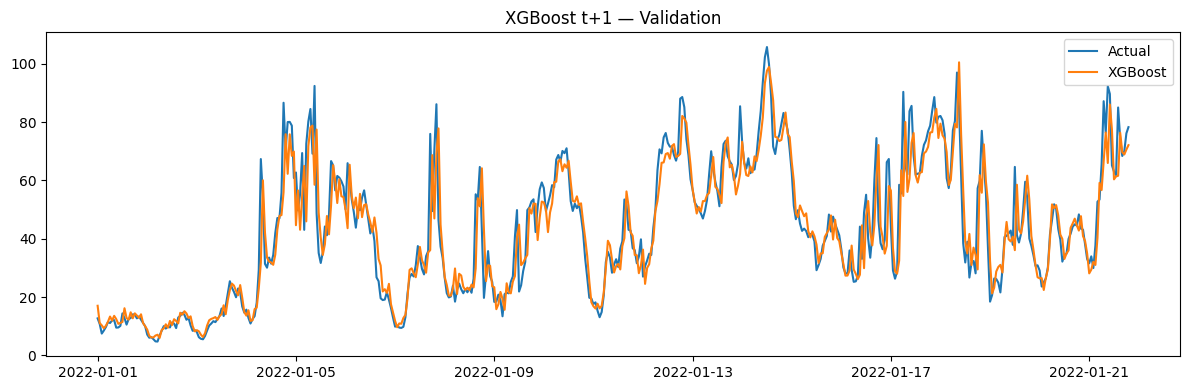

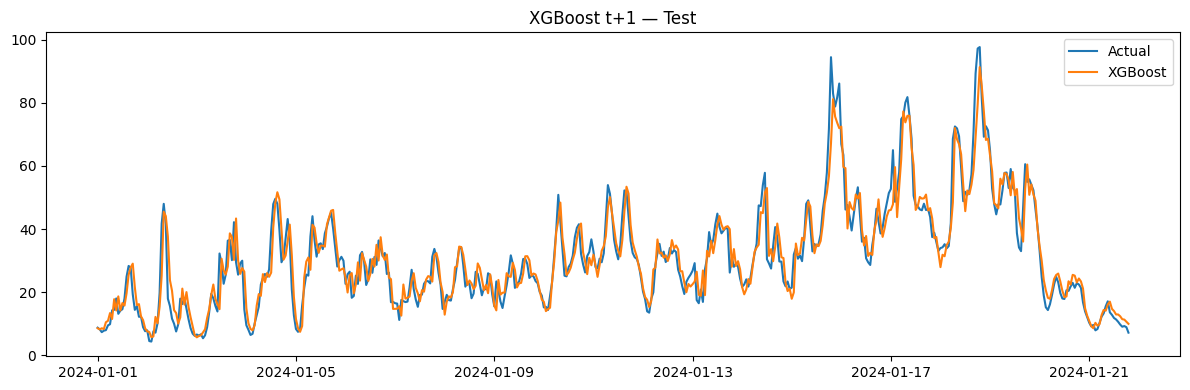

In [ ]:


pred_val = final_booster.predict(
    dval,
    iteration_range=(0, final_booster.best_iteration + 1)
)

pred_test = final_booster.predict(
    dtest,
    iteration_range=(0, final_booster.best_iteration + 1)
)

N = 500

plt.figure(figsize=(12,4))
plt.plot(val_sup.index[:N], y_val[:N], label="Actual")
plt.plot(val_sup.index[:N], pred_val[:N], label="XGBoost")
plt.title("XGBoost t+1 — Validation")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(test_sup.index[:N], y_test[:N], label="Actual")
plt.plot(test_sup.index[:N], pred_test[:N], label="XGBoost")
plt.title("XGBoost t+1 — Test")
plt.legend()
plt.tight_layout()
plt.show()

###8.6 Learning Curve


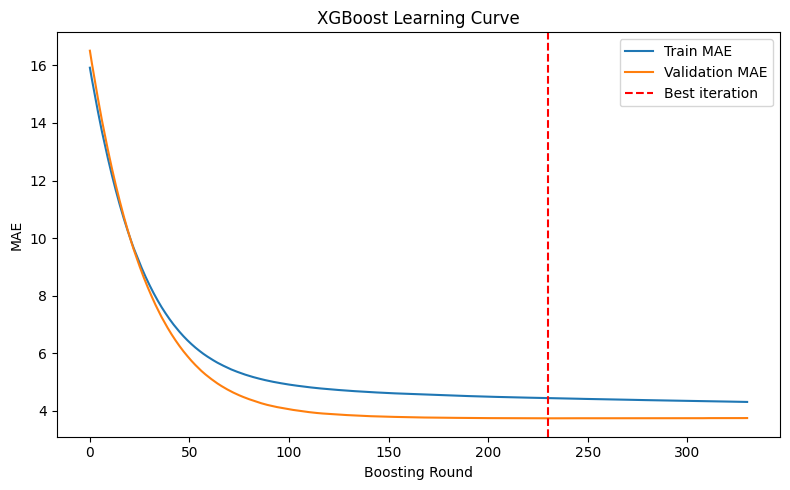

In [ ]:
train_mae_curve = final_evals["train"]["mae"]
val_mae_curve   = final_evals["val"]["mae"]

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_mae_curve, label="Train MAE")
plt.plot(val_mae_curve, label="Validation MAE")
plt.axvline(final_booster.best_iteration, linestyle="--", color="red", label="Best iteration")
plt.legend()
plt.title("XGBoost Learning Curve")
plt.xlabel("Boosting Round")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()

### 9.LSTM Model

9.1 Feature Scaling

In [ ]:
# ============================================================
# 9.1 SCALE (fit on TRAIN only)
# ============================================================

X_FEATURE_COLS = [c for c in train_lstm_df.columns if c != TARGET_COL]

feature_scaler = RobustScaler()
target_scaler  = RobustScaler()

feature_scaler.fit(train_lstm_df[X_FEATURE_COLS].dropna().values)
target_scaler.fit(train_lstm_df[[TARGET_COL]].dropna().values)

def transform_split(df_split: pd.DataFrame) -> pd.DataFrame:
    Xs = pd.DataFrame(index=df_split.index, columns=X_FEATURE_COLS, dtype=float)
    ys = pd.Series(index=df_split.index, dtype=float, name=TARGET_COL)

    mX = df_split[X_FEATURE_COLS].notna().all(axis=1)
    if mX.any():
        Xs.loc[mX, X_FEATURE_COLS] = feature_scaler.transform(df_split.loc[mX, X_FEATURE_COLS].values)

    my = df_split[TARGET_COL].notna()
    if my.any():
        ys.loc[my] = target_scaler.transform(df_split.loc[my, [TARGET_COL]].values).ravel()

    out = Xs.copy()
    out[TARGET_COL] = ys
    return out

train_scaled_df = transform_split(train_lstm_df)
val_scaled_df   = transform_split(val_lstm_df)
test_scaled_df  = transform_split(test_lstm_df)

9.2 Sequence Builder

In [ ]:
# ============================================================
# 9.2 SEQUENCE BUILDER
# ============================================================

def make_sequences(scaled_df, window, feature_cols, target_col):
    X_list, y_list, idx_list = [], [], []

    for t in range(window, len(scaled_df)):
        x_win = scaled_df.iloc[t-window:t][feature_cols]
        y_val = scaled_df.iloc[t][target_col]

        if x_win.isna().values.any() or pd.isna(y_val):
            continue

        X_list.append(x_win.values.astype(np.float32))
        y_list.append(np.float32(y_val))
        idx_list.append(scaled_df.index[t])

    return np.array(X_list), np.array(y_list), pd.DatetimeIndex(idx_list)

WINDOW = 48  # keep consistent

X_train, y_train, idx_train = make_sequences(train_scaled_df, WINDOW, X_FEATURE_COLS, TARGET_COL)
X_val,   y_val,   idx_val   = make_sequences(val_scaled_df,   WINDOW, X_FEATURE_COLS, TARGET_COL)
X_test,  y_test,  idx_test  = make_sequences(test_scaled_df,  WINDOW, X_FEATURE_COLS, TARGET_COL)

print("LSTM shapes:", X_train.shape, X_val.shape, X_test.shape)

LSTM shapes: (53769, 48, 20) (13843, 48, 20) (16000, 48, 20)


###9.3 Inverse Transforming

In [ ]:
# ============================================================
# 9.3 HELPERS
# ============================================================

def inv_target(y_scaled):
    return target_scaler.inverse_transform(np.asarray(y_scaled).reshape(-1,1)).ravel()

def mae_rmse_original(y_true_scaled, y_pred_scaled):
    y_true = inv_target(y_true_scaled)
    y_pred = inv_target(y_pred_scaled)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

## 9.4 Model Builder

In [ ]:
# ============================================================
# 9) MODEL BUILDER (tunable)
# ============================================================
def build_model(units=64, dropout=0.2, l2_strength=0.0, lr=1e-3, stacked=False, loss_name="huber"):
    tf.keras.backend.clear_session()

    reg = regularizers.l2(l2_strength) if l2_strength and l2_strength > 0 else None

    layers = []
    if stacked:
        layers.append(LSTM(units, return_sequences=True,
                           input_shape=(WINDOW, len(X_FEATURE_COLS)),
                           kernel_regularizer=reg, recurrent_regularizer=reg))
        layers.append(Dropout(dropout))
        layers.append(LSTM(max(16, units//2), kernel_regularizer=reg, recurrent_regularizer=reg))
    else:
        layers.append(LSTM(units,
                           input_shape=(WINDOW, len(X_FEATURE_COLS)),
                           kernel_regularizer=reg, recurrent_regularizer=reg))

    layers.append(Dropout(dropout))
    layers.append(Dense(1, kernel_regularizer=reg))

    model = Sequential(layers)

    if loss_name == "mse":
        loss_obj = "mse"
    else:
        loss_obj = tf.keras.losses.Huber()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss=loss_obj,
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model

### 9.5 Hyperparameter Tuning

In [ ]:
# ============================================================
# 10) HYPERPARAMETER TUNING (small grid)
#     Select best by validation RMSE (original units)
# ============================================================
search_space = [
    {"units": 64,  "dropout": 0.0, "l2": 0.0,   "lr": 1e-3, "batch": 64,  "stacked": False, "loss": "huber"},
    {"units": 64,  "dropout": 0.2, "l2": 0.0,   "lr": 1e-3, "batch": 64,  "stacked": False, "loss": "huber"},
    {"units": 128, "dropout": 0.2, "l2": 0.0,   "lr": 1e-3, "batch": 64,  "stacked": False, "loss": "huber"},
    {"units": 64,  "dropout": 0.2, "l2": 1e-5,  "lr": 1e-3, "batch": 64,  "stacked": False, "loss": "huber"},
    {"units": 128, "dropout": 0.1, "l2": 1e-5,  "lr": 1e-3, "batch": 64,  "stacked": False, "loss": "huber"},
    {"units": 64,  "dropout": 0.2, "l2": 1e-5,  "lr": 3e-4, "batch": 64,  "stacked": False, "loss": "huber"},
    {"units": 64,  "dropout": 0.2, "l2": 1e-5,  "lr": 1e-3, "batch": 128, "stacked": False, "loss": "huber"},
    # Try MSE (less smoothing)
    {"units": 128, "dropout": 0.1, "l2": 1e-5,  "lr": 1e-3, "batch": 64,  "stacked": False, "loss": "mse"},
    # Stacked LSTM option
    {"units": 64,  "dropout": 0.2, "l2": 1e-5,  "lr": 1e-3, "batch": 64,  "stacked": True,  "loss": "huber"},
]

TUNE_EPOCHS = 30
TUNE_PATIENCE = 6

tune_rows = []
best = {"val_rmse": np.inf, "params": None}

print("\n=== LSTM Hyperparameter tuning ===")
for i, hp in enumerate(search_space, start=1):
    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    model_tmp = build_model(
        units=hp["units"],
        dropout=hp["dropout"],
        l2_strength=hp["l2"],
        lr=hp["lr"],
        stacked=hp["stacked"],
        loss_name=hp["loss"]
    )

    reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5, verbose=0)
    early_stop = EarlyStopping(monitor="val_loss", patience=TUNE_PATIENCE, restore_best_weights=True)

    model_tmp.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=TUNE_EPOCHS,
        batch_size=hp["batch"],
        shuffle=False,
        verbose=0,
        callbacks=[reduce_lr, early_stop]
    )

    pred_train_scaled = model_tmp.predict(X_train, verbose=0).ravel()
    pred_val_scaled   = model_tmp.predict(X_val,   verbose=0).ravel()

    train_mae, train_rmse = mae_rmse_original(y_train, pred_train_scaled)
    val_mae, val_rmse     = mae_rmse_original(y_val,   pred_val_scaled)

    gap = val_rmse - train_rmse

    row = {**hp,
           "trial": i,
           "train_rmse": train_rmse, "val_rmse": val_rmse,
           "train_mae": train_mae,   "val_mae": val_mae,
           "gap_rmse": gap}
    tune_rows.append(row)

    print(f"Trial {i:02d} | val RMSE={val_rmse:.4f} (train RMSE={train_rmse:.4f}, gap={gap:.4f}) | {hp}")

    if val_rmse < best["val_rmse"]:
        best["val_rmse"] = val_rmse
        best["params"] = hp

tune_df = pd.DataFrame(tune_rows).sort_values("val_rmse")
print("\n=== Tuning results (sorted by val_rmse) ===")
print(tune_df[["trial","units","dropout","l2","lr","batch","stacked","loss",
               "train_rmse","val_rmse","gap_rmse","train_mae","val_mae"]].round(4))

best_params = best["params"]
print("\nBest params:", best_params)
print("Best val_rmse:", round(best["val_rmse"], 4))



=== LSTM Hyperparameter tuning ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Trial 01 | val RMSE=7.2623 (train RMSE=9.4474, gap=-2.1850) | {'units': 64, 'dropout': 0.0, 'l2': 0.0, 'lr': 0.001, 'batch': 64, 'stacked': False, 'loss': 'huber'}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Trial 02 | val RMSE=7.2195 (train RMSE=9.1313, gap=-1.9118) | {'units': 64, 'dropout': 0.2, 'l2': 0.0, 'lr': 0.001, 'batch': 64, 'stacked': False, 'loss': 'huber'}


...

Trial 07 | val RMSE=7.2282 (train RMSE=9.2607, gap=-2.0325) | {'units': 64, 'dropout': 0.2, 'l2': 1e-05, 'lr': 0.001, 'batch': 128, 'stacked': False, 'loss': 'huber'}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Trial 08 | val RMSE=7.2419 (train RMSE=9.5531, gap=-2.3112) | {'units': 128, 'dropout': 0.1, 'l2': 1e-05, 'lr': 0.001, 'batch': 64, 'stacked': False, 'loss': 'mse'}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Trial 09 | val RMSE=7.2355 (train RMSE=9.1130, gap=-1.8775) | {'units': 64, 'dropout': 0.2, 'l2': 1e-05, 'lr': 0.001, 'batch': 64, 'stacked': True, 'loss': 'huber'}

=== Tuning results (sorted by val_rmse) ===
   trial  units  dropout   l2      lr  batch  stacked   loss  train_rmse  \
5      6     64      0.2  0.0  0.0003     64    False  huber      9.2696   
4      5    128      0.1  0.0  0.0010     64    False  huber      9.2305   
1      2     64      0.2  0.0  0.0010     64    False  huber      9.1313   
3      4     64      0.2  0.0  0.0010     64    False  huber      9.3836   
6      7     64      0.2  0.0  0.0010    128    False  huber      9.2607   
8      9     64      0.2  0.0  0.0010     64     True  huber      9.1130   
7      8    128      0.1  0.0  0.0010     64    False    mse      9.5531   
2      3    128      0.2  0.0  0.0010     64    False  huber      9.5090   
0      1     64      0.0  0.0  0.0010     64    False  huber      9.4474   

   val_rmse  gap_rmse  train_

9.6 Final Training

In [ ]:
# ============================================================
# 11) FINAL TRAINING (best params, longer training)
# ============================================================
FINAL_EPOCHS = 60
FINAL_PATIENCE = 10

tf.random.set_seed(SEED)
np.random.seed(SEED)

final_model = build_model(
    units=best_params["units"],
    dropout=best_params["dropout"],
    l2_strength=best_params["l2"],
    lr=best_params["lr"],
    stacked=best_params["stacked"],
    loss_name=best_params["loss"]
)

reduce_lr_final = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5, verbose=1)
early_stop_final = EarlyStopping(monitor="val_loss", patience=FINAL_PATIENCE, restore_best_weights=True)

history = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=FINAL_EPOCHS,
    batch_size=best_params["batch"],
    shuffle=False,
    verbose=1,
    callbacks=[reduce_lr_final, early_stop_final]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0852 - mae: 0.3074 - val_loss: 0.0386 - val_mae: 0.2032 - learning_rate: 3.0000e-04
Epoch 2/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0660 - mae: 0.2662 - val_loss: 0.0365 - val_mae: 0.1961 - learning_rate: 3.0000e-04
Epoch 3/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0612 - mae: 0.2545 - val_loss: 0.0353 - val_mae: 0.1917 - learning_rate: 3.0000e-04
Epoch 4/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0587 - mae: 0.2478 - val_loss: 0.0345 - val_mae: 0.1870 - learning_rate: 3.0000e-04
Epoch 5/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0570 - mae: 0.2433 - val_loss: 0.0342 - val_mae: 0.1858 - learning_rate: 3.0000e-04
Epoch 6/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0563 - mae: 0.2410 - val_loss: 0.0337 - val_mae: 0.1820 - learning_rate: 3.0000e-04
Epoch 7/60
841/841 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0558 - mae: 0.2401 - val_loss: 0.0335 - val_mae: 0.1816 - lear

### 9.7 Evaluation

In [ ]:
# ============================================================
# 12) EVALUATION (original units)
# ============================================================

pred_val_scaled  = final_model.predict(X_val,  verbose=0).ravel()
pred_test_scaled = final_model.predict(X_test, verbose=0).ravel()

val_mae, val_rmse   = mae_rmse_original(y_val, pred_val_scaled)
test_mae, test_rmse = mae_rmse_original(y_test, pred_test_scaled)

print("\n=== FINAL LSTM ===")
print("Best params:", best_params)
print(f"Validation MAE : {val_mae:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")
print(f"Test MAE       : {test_mae:.4f}")
print(f"Test RMSE      : {test_rmse:.4f}")


=== FINAL LSTM ===
Best params: {'units': 64, 'dropout': 0.2, 'l2': 1e-05, 'lr': 0.0003, 'batch': 64, 'stacked': False, 'loss': 'huber'}
Validation MAE : 5.0526
Validation RMSE: 7.2375
Test MAE       : 4.7179
Test RMSE      : 6.6763


### 9.7 Prediction Curve

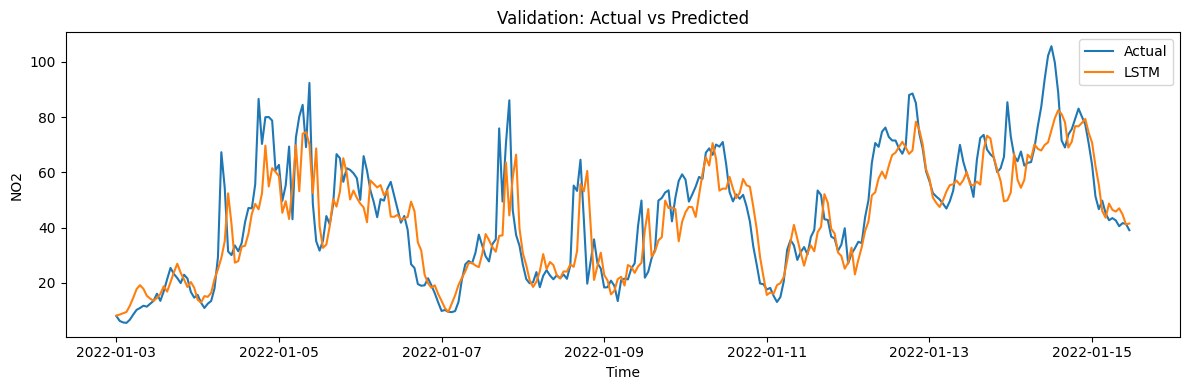

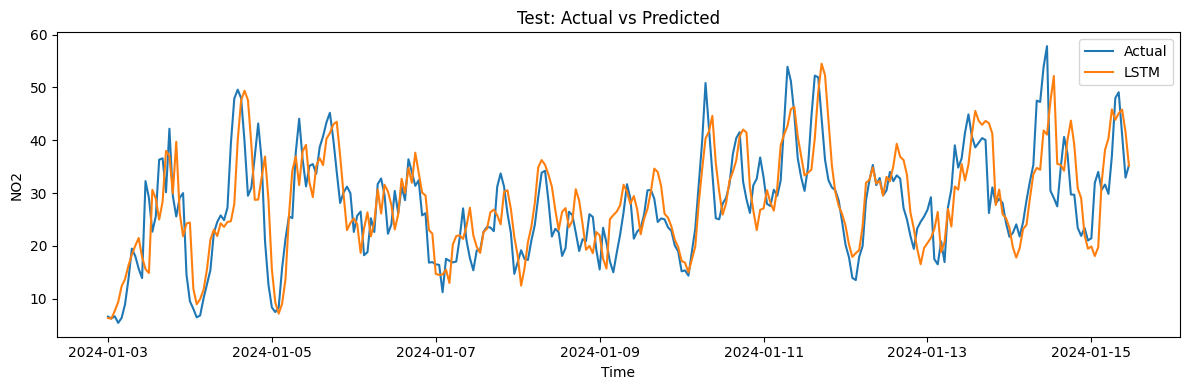

In [ ]:
# ============================================================
# 13) Prediction Plots
# ============================================================

# Inverse-transform true and predicted values
y_val_true  = inv_target(y_val)
y_test_true = inv_target(y_test)

y_val_pred  = inv_target(pred_val_scaled)
y_test_pred = inv_target(pred_test_scaled)

# Validation plot
N = min(300, len(y_val_true))

plt.figure(figsize=(12,4))
plt.plot(idx_val[:N], y_val_true[:N], label="Actual")
plt.plot(idx_val[:N], y_val_pred[:N], label="LSTM")
plt.title("Validation: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("NO2")
plt.legend()
plt.tight_layout()
plt.show()

# Test plot
N = min(300, len(y_test_true))

plt.figure(figsize=(12,4))
plt.plot(idx_test[:N], y_test_true[:N], label="Actual")
plt.plot(idx_test[:N], y_test_pred[:N], label="LSTM")
plt.title("Test: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("NO2")
plt.legend()
plt.tight_layout()
plt.show()


## 9.8 Loss Curve

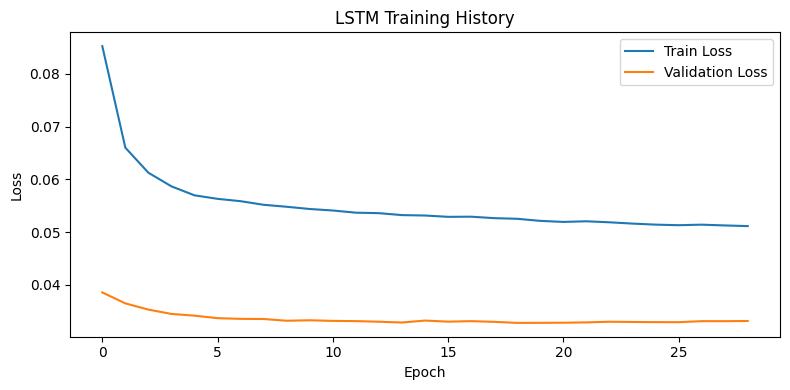

In [ ]:
# ============================================================
# Training History Plot
# ============================================================

hist_df = pd.DataFrame(history.history)

plt.figure(figsize=(8,4))
plt.plot(hist_df["loss"], label="Train Loss")
plt.plot(hist_df["val_loss"], label="Validation Loss")
plt.title("LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Make sure this matches your dataframe column exactly
TARGET_COL = "target_t_plus_1"   # change to _24 if needed

def split_stats(y, name):
    return pd.Series({
        "count": y.count(),
        "mean": y.mean(),
        "std": y.std(),
        "p95": y.quantile(0.95),
        "p99": y.quantile(0.99),
        "max": y.max()
    }, name=name)

# train_sup/val_sup/test_sup must contain TARGET_COL
stats = pd.concat([
    split_stats(train_sup[TARGET_COL], "train"),
    split_stats(val_sup[TARGET_COL], "val"),
    split_stats(test_sup[TARGET_COL], "test"),
], axis=1)

stats.round(2)

,train,val,test
count,57134.00,14821.00,16678.00
mean,35.90,24.24,22.70
std,20.18,15.27,13.45
p95,72.85,54.94,49.59
p99,91.63,74.30,65.14
max,157.65,105.71,97.63


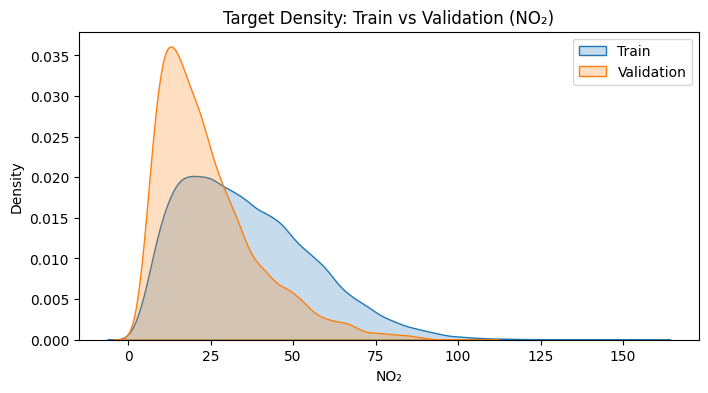

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,4))

# sns.kdeplot creates a smoothed distribution curve
sns.kdeplot(train_sup["target_t_plus_1"].dropna(), label="Train", fill=True)
sns.kdeplot(val_sup["target_t_plus_1"].dropna(), label="Validation", fill=True)

plt.title("Target Density: Train vs Validation (NO₂)")
plt.xlabel("NO₂")
plt.ylabel("Density")
plt.legend()
plt.show()
